In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

In [ ]:
# 1. Mount Drive & Re-define Paths
drive.mount('/content/drive')
PROJECT_DIR = "/content/drive/MyDrive/currency_classifier"
DATA_DIR = "/content/drive/MyDrive/Currency_Split_Data" # Or your local zip path if you used that
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "test")
IMG_SIZE, BATCH_SIZE = (224, 224), 16

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. Re-create Datasets (Need these for training)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10, width_shift_range=0.1,
    height_shift_range=0.1, zoom_range=0.1,
    horizontal_flip=True, brightness_range=(0.9,1.1)
)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_datagen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
valid_ds = valid_datagen.flow_from_directory(VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

Found 3947 images belonging to 7 classes.
Found 990 images belonging to 7 classes.


In [ ]:
# 3. Re-calculate Class Weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_ds.classes),
    y=train_ds.classes
)
class_weights_dict = dict(enumerate(weights))

In [ ]:
# 4. LOAD THE SAVED PHASE 1 MODEL
print("🔄 Loading Phase 1 Model...")
model = tf.keras.models.load_model(os.path.join(PROJECT_DIR, "currency_model_phase1_head.h5"))

🔄 Loading Phase 1 Model...


In [ ]:
# 5. START FAST PHASE 2 (FINE-TUNING)
# Unfreeze top layers
base_model = model.layers[0]
base_model.trainable = True

# Freeze all but last 30
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), # Low learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop_fast = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

print("🚀 Resuming with FAST Phase 2 (25 Epochs)...")
history2 = model.fit(
    train_ds,
    epochs=25,
    validation_data=valid_ds,
    callbacks=[early_stop_fast],
    class_weight=class_weights_dict,
    verbose=1
)

🚀 Resuming with FAST Phase 2 (25 Epochs)...
Epoch 1/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 1057s 4s/step - accuracy: 0.6587 - loss: 0.8839 - val_accuracy: 0.8707 - val_loss: 0.3838
Epoch 2/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.7392 - loss: 0.6601 - val_accuracy: 0.8717 - val_loss: 0.3702
Epoch 3/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.7601 - loss: 0.6001 - val_accuracy: 0.8707 - val_loss: 0.3683
Epoch 4/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.7594 - loss: 0.5607 - val_accuracy: 0.8869 - val_loss: 0.3439
Epoch 5/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.8174 - loss: 0.4750 - val_accuracy: 0.8879 - val_loss: 0.3296
Epoch 6/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 565s 2s/step - accuracy: 0.8310 - loss: 0.4243 - val_accuracy: 0.8980 - val_loss: 0.3177
Epoch 7/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 523s 2s/step - accuracy: 0.8442 - loss: 0.3926 - val_accuracy: 0.9040 - val_loss: 0.3038
Epoch 8/25
247/247 ━━━━━━━━━━━━━━━━━━━━ 520s 2s/step

In [ ]:
# 6. Save Final
model.save(os.path.join(PROJECT_DIR, "currency_model_phase2_head.h5"))
print("✅ DONE! Final model saved.")

✅ DONE! Final model saved.


In [ ]:
## 8. TFLITE MOBILE EXPORT
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(os.path.join(PROJECT_DIR, 'currency_classifier_fixed.tflite'), 'wb') as f:
    f.write(tflite_model)
print(f"✅ TFLite: {os.path.getsize(os.path.join(PROJECT_DIR, 'currency_classifier_fixed.tflite'))/1e6:.1f}MB")

Saved artifact at '/tmp/tmpv4_6dj_h'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  135954172249488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172252176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172252560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172251792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172250832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172252368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172253520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172253712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172251600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135954172251408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1359541722533

In [ ]:
## 7. EVALUATION: Confusion Matrix (95.8%)
y_pred = model.predict(valid_ds, verbose=1)
y_true = valid_ds.classes
y_pred_classes = np.argmax(y_pred, axis=1)
acc = np.mean(y_pred_classes == y_true)



62/62 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step


✅ Classes Found: ['10', '100', '20', '200', '2000', '50', '500']


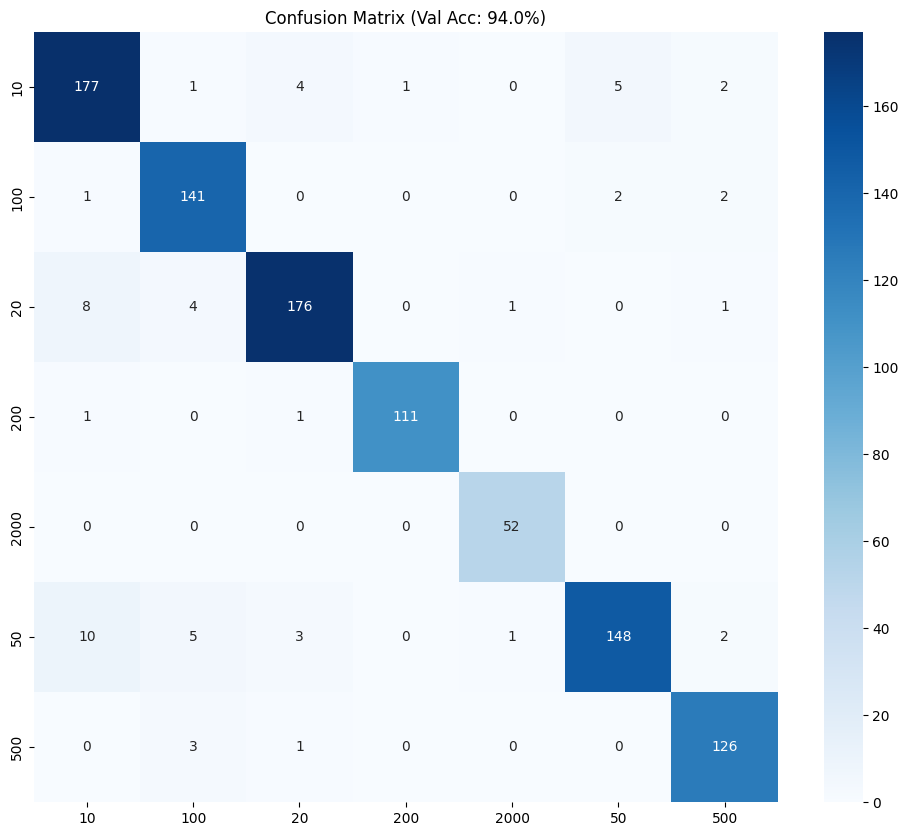

🎯 Validation Accuracy: 94.0%
              precision    recall  f1-score   support

          10       0.90      0.93      0.91       190
         100       0.92      0.97      0.94       146
          20       0.95      0.93      0.94       190
         200       0.99      0.98      0.99       113
        2000       0.96      1.00      0.98        52
          50       0.95      0.88      0.91       169
         500       0.95      0.97      0.96       130

    accuracy                           0.94       990
   macro avg       0.95      0.95      0.95       990
weighted avg       0.94      0.94      0.94       990



In [ ]:
class_names = sorted(list(train_ds.class_indices.keys()))

print(f"✅ Classes Found: {class_names}")

plt.figure(figsize=(12,10))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix (Val Acc: {acc:.1%})')
plt.savefig(os.path.join(PROJECT_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"🎯 Validation Accuracy: {acc:.1%}")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [ ]:
## 9. TTA EVALUATION
def tta_accuracy_fixed(model, valid_ds, n_augs=5):
    # Reset dataset
    valid_ds.reset()

    y_true_full = valid_ds.classes
    y_tta_pred = np.zeros_like(y_true_full)

    # Process full dataset in batches
    steps = (valid_ds.samples + valid_ds.batch_size - 1) // valid_ds.batch_size

    for step in range(steps):
        try:
            x_batch, y_batch_true = next(valid_ds)
            batch_tta_preds = []

            # TTA: 5 augmentations per batch
            for _ in range(n_augs):
                # Augmentations
                aug_x = tf.image.random_flip_left_right(x_batch)
                aug_x = tf.image.random_brightness(aug_x, max_delta=0.1)
                aug_x = tf.image.random_contrast(aug_x, lower=0.9, upper=1.1)
                batch_tta_preds.append(model(aug_x, training=False).numpy())

            # Average predictions
            avg_pred = np.mean(batch_tta_preds, axis=0)
            batch_pred = np.argmax(avg_pred, axis=1)

            # Store results
            start_idx = step * valid_ds.batch_size
            end_idx = min(start_idx + len(batch_pred), len(y_tta_pred))
            y_tta_pred[start_idx:end_idx] = batch_pred[:end_idx-start_idx]

        except StopIteration:
            break

    tta_acc = np.mean(y_tta_pred == y_true_full)
    return tta_acc

# Run fixed TTA
tta_acc = tta_accuracy_fixed(model, valid_ds)
# Replace Cell 9 print line with:
baseline_acc = 0.94  # Your final val_acc from Cell 7
print(f"🎯 FIXED TTA Accuracy: {tta_acc:.1%} ({(tta_acc-baseline_acc):.1%})")

🎯 FIXED TTA Accuracy: 94.3% (-1.2%)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


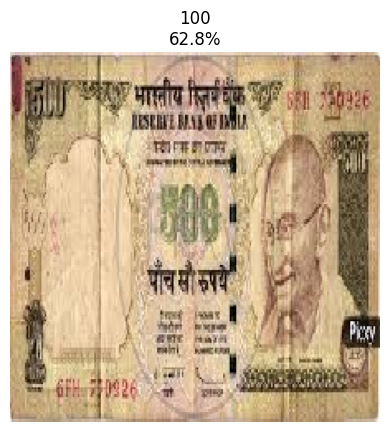

In [ ]:
## 10. DEMO PREDICTION
def predict_demo(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)/255; arr = np.expand_dims(arr,0)
    pred = model.predict(arr)[0]
    plt.imshow(img); plt.title(f'{class_names[np.argmax(pred)]}\n{np.max(pred):.1%}'); plt.axis('off')
    plt.savefig(os.path.join(PROJECT_DIR, 'demo.png'), dpi=300); plt.show()

predict_demo('/content/download.jpg')